# MOSAIC : β Pic b


This tutorial is intended as a quick start when using multiple observations. 


We will use low resolution Gemini/GPI YJHK-band, photometric points and medium resolution VTLI/GRAVITY K-band data of β Pic b. These observations and example model were published in [GRAVITY collaboration et al (2020)](https://arxiv.org/pdf/1912.04651).

## Imports

In [1]:
# Generic packages
import matplotlib.pyplot as plt

# ForMoSA modules
# For the interpolation & sampling
from ForMoSA.global_file import GlobFile
from ForMoSA.adapt.adapt_obs_mod import launch_adapt
from ForMoSA.nested_sampling.nested_sampling import launch_nested_sampling
# For the plots
from ForMoSA.plotting.plotting_class import PlottingForMoSA

## 0. Setup

You need to create a config file with extension ``.ini`` and modify the parameters. Learn more about our config files in it's specific tutorial.

In this exemple, let's create a ``config_ref.ini`` using the empty ``config.ini`` available in the tutorial

In [2]:
base_path = '/home/mravet/Documents/These/FORMOSA/OUTPUTS/Channel1/'

# creating a default config file
config_file_path = base_path + 'config.ini' # This is an empty config file
global_params = GlobFile(config_file_path) # Default parameters are added

# Define the grid parameters (check the ExoREM tutorial for more information)
global_params.par1 = "uniform", 1000, 2000
global_params.par2 = "uniform", 3.0, 5.0
global_params.par3 = "uniform", -0.5, 1.0
global_params.par4 = "uniform", 0.1, 0.8

Now, since we have two observations, we can define extra-grid parameters separatly. For this exemple, lets say we want to fit a radial velocity for the VLT/GRAVITY observation, but not for the Gemini/GPI observation :

In [3]:
global_params.rv = 'NA', 'NA', 'NA',      'uniform', -50, 50 # GPI is the first observation in the file 

# Don't forget to save your changes !
global_params.config.filename = global_params.result_path + 'config_update.ini'

## 1. Interpolate the grid

Once everything is setup, we start by adapting the models and observations. 

The grid of models is interpolated for this, but you don't need to repeat this step once you've adapted the grid for a specific dataset. 

(Answer 'no' only the first time)

In [4]:
# Have you already interpolated the grids for this data? 
y_n_par = 'yes'
#y_n_par = 'no' # Only answer no the first time, then comment to save time

launch_adapt(global_params, justobs=y_n_par)

## 2. Lunch Nested Sampling 

Once the grid is interpolated, we proceed with the nested sampling. For this case we are using the Python package nestle. 

In [9]:
launch_nested_sampling(global_params)

- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
-> Likelihood functions check-ups

1_BetaPic_b_GPI_MOSAIC_photo will be computed with chi2

2_BetaPic-b_GRAVITY-R500_smoothcov_WAVformat will be computed with chi2

Done !

it=  1894 logz=-561.17784347 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
-> Nestle  
 
The code spent 14.0 min to run.
niter: 1895
ncall: 53299
nsamples: 1995
logz: -560.920 +/-  0.398
h: 15.866




## 3. Plotting the outcomes

ForMoSA has been designed with a plotting class. Bellow we show 4 main features: 

- Plotting corner-plots
- Plotting spectra and residuals
- Plotting chains 
- Accessing the different parameters

All plotting functions return the fig object. Therefore you can edit the axes, overplot text/curves, save, etc...

We need to start by initializing the plotting class as follows.

In [8]:
# Initialize the plotting class 
plotForMoSA = PlottingForMoSA(global_params=global_params) # You can directly give the global parameters if they are alreadt initialized
plotForMoSA._get_posteriors(burn_in=0) # Burn in controls how much of the convergence chain you keep to estimate your final values

### PLOT Corner

ForMoSA - Corner plot


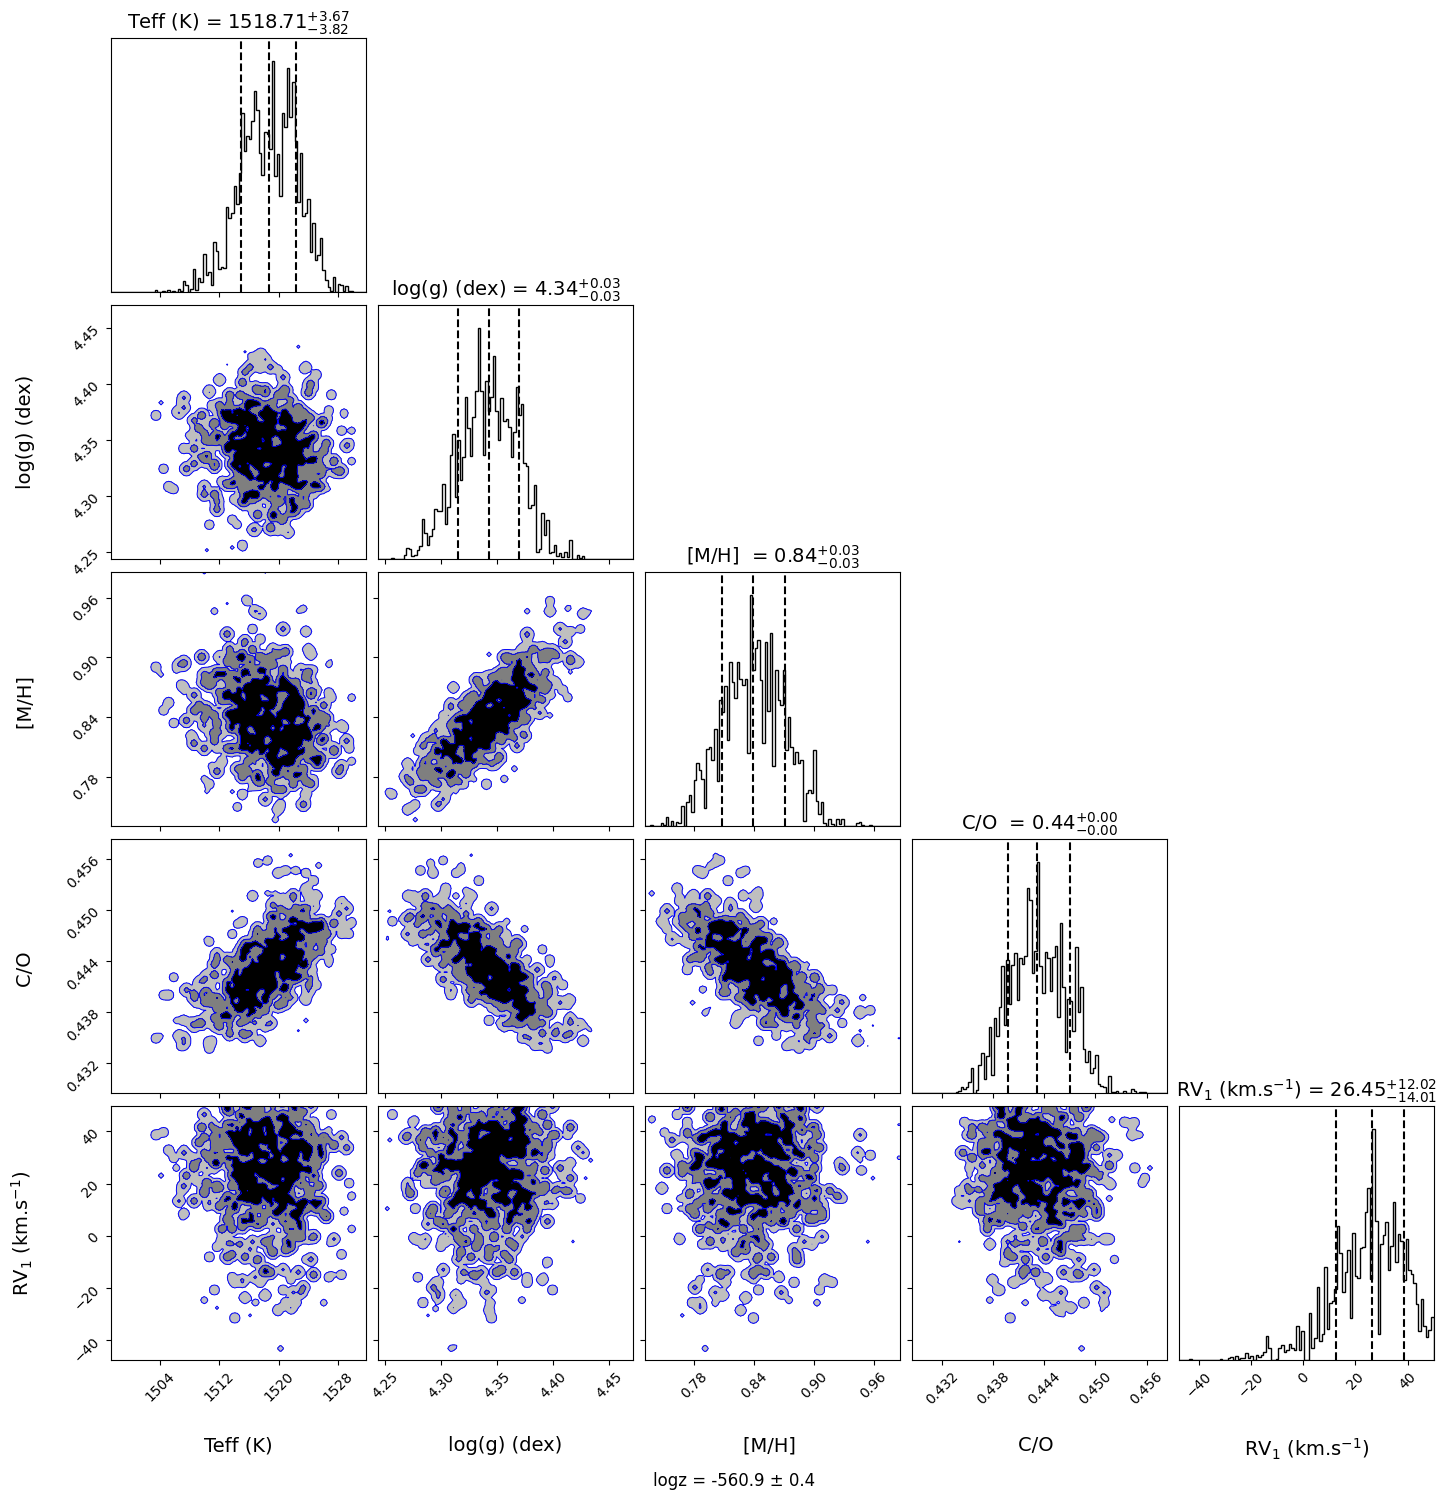

In [9]:
fig = plotForMoSA.plot_corner(levels_sig=[0.997, 0.95, 0.68], bins=100, quantiles=(0.16, 0.5, 0.84))
plt.show()

### Plot Spectrum and Residuals

ForMoSA - Best fit and residuals plot


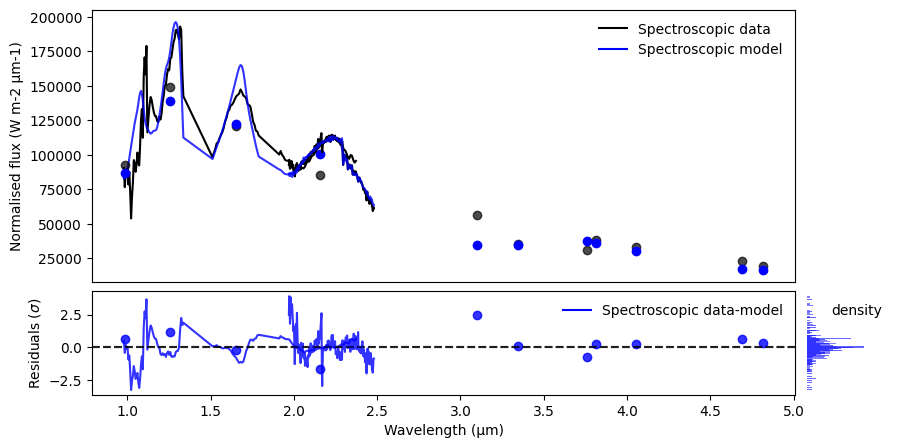

In [11]:
# Lets renormalized the data in model-flux unit using norm='yes'
fig, ax, axr, axr2 = plotForMoSA.plot_fit(figsize=(10, 5), uncert='no', trans='no', logy='no', logx='no', norm='yes')
plt.show()

### Plot Chains of posteriors

ForMoSA - Posteriors chains for each parameter


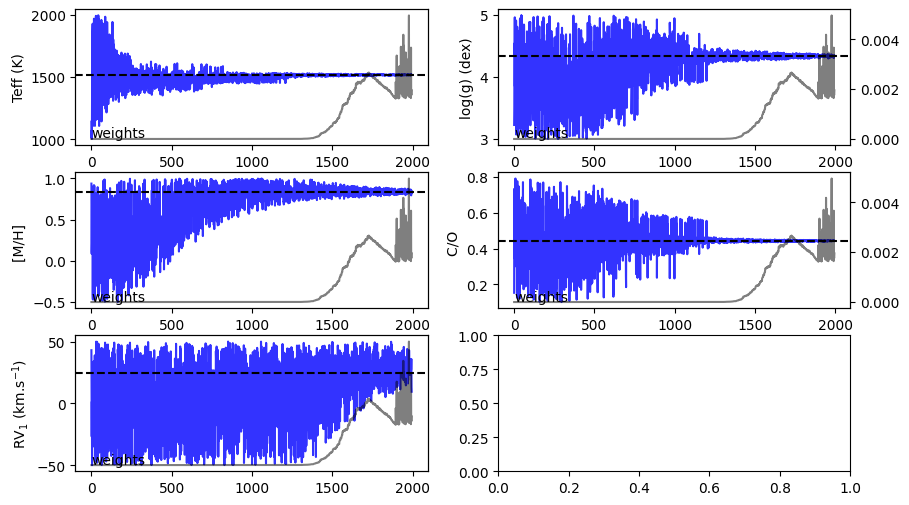

In [12]:
fig, axs = plotForMoSA.plot_chains(figsize=(10,6))
plt.show()

### Access information

You can access different parametes since we are working with a class


In [30]:
posteriors_chains = plotForMoSA.posterior_to_plot
posteriors_names = plotForMoSA.posteriors_names